# Actividad 1: diagnóstico y preparación de datos

## Identificación del conjunto de datos

**Nombre:** *Student Performance Factors Dataset*  
**Autor:** Mosap Abdel-Ghany  
**Fuente:** Kaggle  
**Liga de acceso:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  
**Fecha de consulta:** 15 de agosto de 2026  
**Actualización mostrada por Kaggle:** `Updated 7 months ago` (aproximadamente enero de 2026). La vista pública consultada no expone el día calendario exacto, por lo que no es posible confirmarlo sin inventar el dato. La actualización indicada es menor a tres años.  
**Referencia del dataset:** Abdel-Ghany, M. (2025). *Student Performance Factors Dataset* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset

## Contexto y posible tarea predictiva

Este conjunto de datos estructurado contiene variables académicas, personales, familiares y escolares relacionadas con el desempeño estudiantil. Cada registro representa a un estudiante y cada columna describe una característica asociada con sus hábitos de estudio, asistencia, antecedentes académicos, recursos disponibles, condiciones familiares o entorno escolar.

La posible variable objetivo es `Exam_Score`, porque contiene un puntaje numérico. En una etapa posterior podría plantearse un problema de **aprendizaje supervisado de regresión** para estimar el puntaje esperado a partir de las variables predictoras. Un modelo de este tipo podría apoyar el análisis preventivo y la identificación de estudiantes que podrían requerir recursos adicionales. Sus predicciones no demostrarían causalidad ni deberían utilizarse para decisiones automáticas de alto impacto sin validar rendimiento, representatividad y posibles sesgos.

## Objetivo de la actividad

Realizar un diagnóstico inicial del conjunto de datos y aplicar de forma reproducible técnicas de exploración, limpieza, codificación y escalamiento para obtener una versión numérica y preparada para una tarea posterior de aprendizaje automático, conservando `Exam_Score` como posible variable objetivo.

## 1. Carga y revisión inicial


In [22]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 30)
BASE_DIR = Path('/content') if Path('/content').exists() else Path.cwd()
DATA_PATH = BASE_DIR / 'StudentPerformanceFactors.csv'
OUTPUT_PATH = BASE_DIR / 'csv_limpio.csv'
df_original = pd.read_csv(DATA_PATH)
print(f'Archivo: {DATA_PATH.name}')
print(f'Filas: {df_original.shape[0]:,} | Columnas: {df_original.shape[1]}')
print('Columnas:')
print(df_original.columns.tolist())


Archivo: StudentPerformanceFactors.csv
Filas: 6,607 | Columnas: 20
Columnas:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [23]:
resumen_estructura = pd.DataFrame({
    'tipo': df_original.dtypes.astype(str),
    'faltantes': df_original.isna().sum(),
    'valores_unicos': df_original.nunique(dropna=False)
})
print(resumen_estructura.to_string())
print(f'\nTotal de valores faltantes: {df_original.isna().sum().sum()}')
print(f'Registros duplicados: {df_original.duplicated().sum()}')


                              tipo  faltantes  valores_unicos
Hours_Studied                int64          0              41
Attendance                   int64          0              41
Parental_Involvement        object          0               3
Access_to_Resources         object          0               3
Extracurricular_Activities  object          0               2
Sleep_Hours                  int64          0               7
Previous_Scores              int64          0              51
Motivation_Level            object          0               3
Internet_Access             object          0               2
Tutoring_Sessions            int64          0               9
Family_Income               object          0               3
Teacher_Quality             object         78               4
School_Type                 object          0               2
Peer_Influence              object          0               3
Physical_Activity            int64          0               7
Learning

In [24]:
print('Muestra de cinco registros:')
print(df_original.head().to_string(index=False))
print('\nEstadísticas descriptivas (variables numéricas):')
print(df_original.describe().round(2).to_string())
print('\nEstadísticas descriptivas (variables categóricas):')
print(df_original.describe(include='object').to_string())


Muestra de cinco registros:
 Hours_Studied  Attendance Parental_Involvement Access_to_Resources Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality School_Type Peer_Influence  Physical_Activity Learning_Disabilities Parental_Education_Level Distance_from_Home Gender  Exam_Score
            23          84                  Low                High                         No            7               73              Low             Yes                  0           Low          Medium      Public       Positive                  3                    No              High School               Near   Male          67
            19          64                  Low              Medium                         No            8               59              Low             Yes                  2        Medium          Medium      Public       Negative                  4                    No                  Coll

## 2. Interpretación del estado inicial

El archivo tiene **6,607 filas y 20 columnas**. Las variables numéricas ya están almacenadas como números y las categóricas como texto. Se detectan **235 valores faltantes** en tres columnas categóricas y **0 registros duplicados**. Las categorías observadas son coherentes y de baja cardinalidad. El valor máximo de `Exam_Score` es **101**, superior al límite porcentual de 100 asumido en esta actividad; se revisará como rango imposible. No hay una columna identificadora ni variables constantes.


## 3. Diagnóstico de calidad

Se revisan explícitamente los problemas exigidos: faltantes, duplicados, tipos, categorías, espacios, números como texto, extremos, rangos imposibles, constantes e identificadores. Para valores extremos se usa la regla de 1.5 veces el rango intercuartílico (IQR); un valor atípico estadístico no se elimina automáticamente si sigue siendo plausible.


In [25]:
cat_cols_initial = df_original.select_dtypes(include='object').columns.tolist()
num_cols_initial = df_original.select_dtypes(include=np.number).columns.tolist()
spaces = {c: int(df_original[c].dropna().astype(str).str.strip().ne(df_original[c].dropna().astype(str)).sum()) for c in cat_cols_initial}
constant_cols = [c for c in df_original.columns if df_original[c].nunique(dropna=False) <= 1]
numeric_like_text = []
for c in cat_cols_initial:
    s = df_original[c].dropna().astype(str).str.strip()
    if len(s) and pd.to_numeric(s, errors='coerce').notna().mean() > .95:
        numeric_like_text.append(c)

outlier_counts = {}
for c in num_cols_initial:
    q1, q3 = df_original[c].quantile([.25, .75])
    iqr = q3 - q1
    outlier_counts[c] = int(((df_original[c] < q1 - 1.5*iqr) | (df_original[c] > q3 + 1.5*iqr)).sum())

diagnostico = pd.DataFrame([
    ['Valores faltantes', 'Teacher_Quality; Parental_Education_Level; Distance_from_Home', '78 + 90 + 67 = 235 valores', 'Imputar con la moda de cada variable; son categóricas y la pérdida de filas no es necesaria.'],
    ['Duplicados', 'Todas', f'{df_original.duplicated().sum()} filas duplicadas', 'Aplicar drop_duplicates; no cambia filas si no existen duplicados.'],
    ['Tipos incorrectos / números como texto', 'Todas', f'Numéricas como texto detectadas: {numeric_like_text or "ninguna"}', 'Conservar tipos; incluir conversión defensiva de columnas numéricas.'],
    ['Espacios adicionales / categorías inconsistentes', 'Categóricas', f'Espacios externos detectados: {sum(spaces.values())}; categorías revisadas', 'Aplicar strip y normalización mediante mapas explícitos.'],
    ['Rango imposible', 'Exam_Score', f'{int((df_original.Exam_Score > 100).sum())} valor > 100; máximo = {df_original.Exam_Score.max()}', 'Eliminar la fila con puntaje > 100 bajo interpretación porcentual; documentar el cambio.'],
    ['Valores extremos (regla IQR)', 'Variables numéricas', str({k:v for k,v in outlier_counts.items() if v}), 'Conservar extremos plausibles; no confundir atípico estadístico con error.'],
    ['Variables constantes', 'Todas', f'{constant_cols or "ninguna"}', 'No se elimina ninguna columna por este criterio.'],
    ['Identificadores sin aporte', 'Todas', 'No existe columna ID', 'No se elimina ninguna columna por este criterio.']
], columns=['Problema detectado','Variable afectada','Evidencia','Tratamiento propuesto'])
print(diagnostico.to_string(index=False))


                              Problema detectado                                             Variable afectada                                                          Evidencia                                                                        Tratamiento propuesto
                               Valores faltantes Teacher_Quality; Parental_Education_Level; Distance_from_Home                                         78 + 90 + 67 = 235 valores Imputar con la moda de cada variable; son categóricas y la pérdida de filas no es necesaria.
                                      Duplicados                                                         Todas                                                 0 filas duplicadas                           Aplicar drop_duplicates; no cambia filas si no existen duplicados.
          Tipos incorrectos / números como texto                                                         Todas                           Numéricas como texto detectadas: ninguna          

## 4. Limpieza básica justificada

1. Se normalizan los nombres de columnas a `snake_case` conservando las etiquetas solicitadas (ya estaban correctas).
2. Se eliminan duplicados con `drop_duplicates`; como había cero, no se pierde información.
3. Se recortan espacios y se estandarizan categorías con mapas explícitos.
4. Se convierten defensivamente las columnas numéricas con `pd.to_numeric`.
5. Se imputan las tres variables categóricas incompletas con su moda: es una solución básica, reproducible y evita eliminar 235 celdas/filas; como limitación, puede reforzar la categoría mayoritaria.
6. Se filtra el único `Exam_Score` mayor que 100, porque se interpreta como porcentaje. Los demás valores atípicos plausibles se conservan.

Documentación de las operaciones utilizadas: `fillna` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) y `drop_duplicates` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html).


In [26]:
df = df_original.copy()
filas_iniciales = len(df)

# 1) Normalización de nombres de columnas
df.columns = (
    df.columns
    .str.strip()
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# 2) Eliminación de registros duplicados
duplicados_eliminados = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# 3) Eliminación de espacios y normalización de categorías
columnas_categoricas = df.select_dtypes(include="object").columns.tolist()

for columna in columnas_categoricas:
    df[columna] = df[columna].str.strip()

normalizaciones = {
    "Parental_Involvement": {
        "low": "Low",
        "medium": "Medium",
        "high": "High",
    },
    "Access_to_Resources": {
        "low": "Low",
        "medium": "Medium",
        "high": "High",
    },
    "Motivation_Level": {
        "low": "Low",
        "medium": "Medium",
        "high": "High",
    },
    "Family_Income": {
        "low": "Low",
        "medium": "Medium",
        "high": "High",
    },
    "Teacher_Quality": {
        "low": "Low",
        "medium": "Medium",
        "high": "High",
    },
    "Distance_from_Home": {
        "near": "Near",
        "moderate": "Moderate",
        "far": "Far",
    },
}

for columna, mapa in normalizaciones.items():
    if columna in df.columns:
        df[columna] = df[columna].map(
            lambda valor: (
                mapa.get(str(valor).strip().lower(), valor)
                if pd.notna(valor)
                else valor
            )
        )

# 4) Conversión defensiva de las variables numéricas
# Se detectan aquí para evitar el error: num_cols_initial is not defined.
columnas_numericas = df.select_dtypes(include="number").columns.tolist()

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

# 5) Imputación de valores faltantes mediante la moda
columnas_para_imputar = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home",
]

imputaciones = {}

for columna in columnas_para_imputar:
    if columna in df.columns:
        faltantes_antes = int(df[columna].isna().sum())

        if faltantes_antes > 0:
            moda = df[columna].mode(dropna=True)

            if not moda.empty:
                valor_moda = moda.iloc[0]
                df[columna] = df[columna].fillna(valor_moda)
            else:
                valor_moda = "Sin información"
                df[columna] = df[columna].fillna(valor_moda)
        else:
            valor_moda = "No fue necesaria"

        imputaciones[columna] = {
            "faltantes_antes": faltantes_antes,
            "valor_utilizado": valor_moda,
        }

# 6) Filtrado del rango válido de Exam_Score
if "Exam_Score" not in df.columns:
    raise KeyError("No se encontró la columna 'Exam_Score'.")

df["Exam_Score"] = pd.to_numeric(df["Exam_Score"], errors="coerce")

mascara_imposibles = (
    df["Exam_Score"].isna()
    | (df["Exam_Score"] < 0)
    | (df["Exam_Score"] > 100)
)

imposibles = int(mascara_imposibles.sum())
df = df.loc[~mascara_imposibles].reset_index(drop=True)

print("Imputaciones:", imputaciones)
print(f"Filas eliminadas por duplicados: {duplicados_eliminados}")
print(f"Filas eliminadas por Exam_Score fuera de [0, 100]: {imposibles}")
print(
    f"Estado limpio: {df.shape[0]:,} filas, "
    f"{df.shape[1]} columnas, "
    f"{int(df.isna().sum().sum())} faltantes y "
    f"{int(df.duplicated().sum())} duplicados."
)

Imputaciones: {'Teacher_Quality': {'faltantes_antes': 78, 'valor_utilizado': 'Medium'}, 'Parental_Education_Level': {'faltantes_antes': 90, 'valor_utilizado': 'High School'}, 'Distance_from_Home': {'faltantes_antes': 67, 'valor_utilizado': 'Near'}}
Filas eliminadas por duplicados: 0
Filas eliminadas por Exam_Score fuera de [0, 100]: 1
Estado limpio: 6,606 filas, 20 columnas, 0 faltantes y 0 duplicados.


## 5. Análisis de `Exam_Score`

Se presentan medidas descriptivas, histograma y diagrama de caja. La línea roja del histograma representa la media. El análisis gráfico se realiza después de retirar el valor imposible 101.


count    6606.000
mean       67.231
std         3.869
min        55.000
25%        65.000
50%        67.000
75%        69.000
max       100.000
Limites IQR: [59.0, 75.0] | Atípicos estadísticos: 103


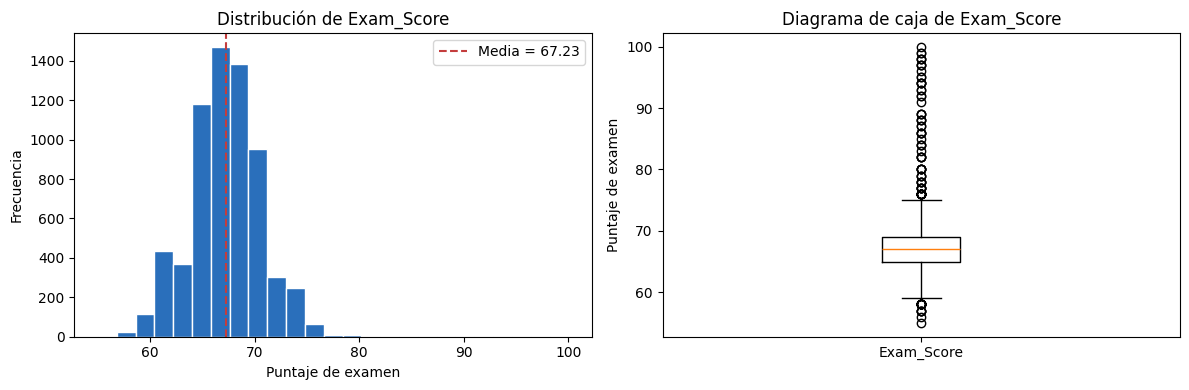

In [27]:
target_desc = df['Exam_Score'].describe().round(3)
q1, q3 = df['Exam_Score'].quantile([.25,.75]); iqr = q3-q1
lo, hi = q1-1.5*iqr, q3+1.5*iqr
target_outliers = int(((df.Exam_Score < lo) | (df.Exam_Score > hi)).sum())
print(target_desc.to_string())
print(f'Limites IQR: [{lo:.1f}, {hi:.1f}] | Atípicos estadísticos: {target_outliers}')

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['Exam_Score'], bins=25, color='#2A6FBB', edgecolor='white')
axes[0].axvline(df['Exam_Score'].mean(), color='#C43D3D', linestyle='--', label=f'Media = {df.Exam_Score.mean():.2f}')
axes[0].set(title='Distribución de Exam_Score', xlabel='Puntaje de examen', ylabel='Frecuencia')
axes[0].legend()
axes[1].boxplot(df['Exam_Score'], vert=True)
axes[1].set(title='Diagrama de caja de Exam_Score', ylabel='Puntaje de examen', xticklabels=['Exam_Score'])
plt.tight_layout()
plt.show()


**Interpretación:** la distribución está concentrada alrededor de 67 puntos y presenta una cola derecha pequeña. La regla IQR marca observaciones altas como atípicas estadísticas; tras retirar 101, sus puntajes permanecen dentro de 0–100 y por ello se conservan. El posible problema para modelado no es su mera rareza, sino que el modelo podría ajustar peor esa zona con pocos casos; debe evaluarse con partición de prueba y métricas de error. La eliminación de 101 se basa en la interpretación porcentual asumida, una limitación que debe contrastarse con el diccionario oficial si estuviera disponible.


## 6. Exploración ampliada

Se estudian `Hours_Studied` y `Attendance` como variables numéricas, y `Parental_Involvement` y `School_Type` como categóricas. Las gráficas tienen títulos y ejes identificados.


       Hours_Studied  Attendance
count        6606.00     6606.00
mean           19.97       79.97
std             5.99       11.55
min             1.00       60.00
25%            16.00       70.00
50%            20.00       80.00
75%            24.00       90.00
max            44.00      100.00
Hours_Studied: 43 atípicos según IQR; rango observado [1, 44]
Attendance: 0 atípicos según IQR; rango observado [60, 100]


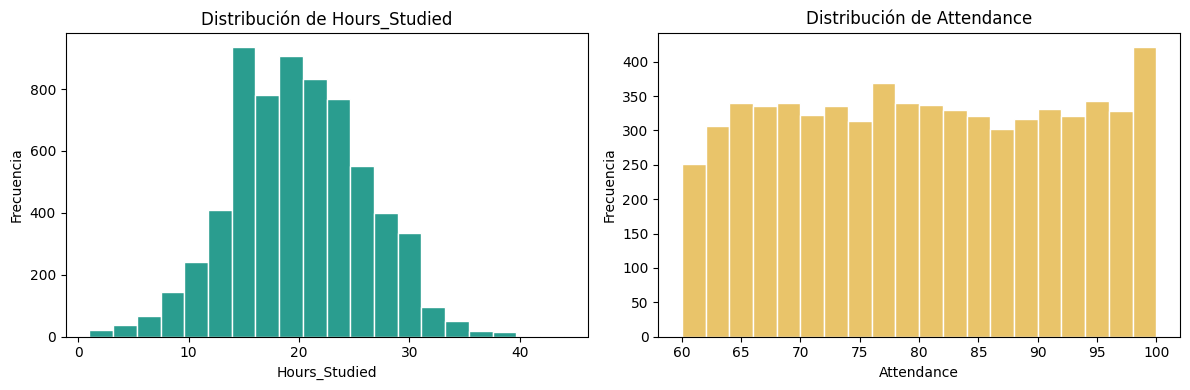

In [28]:
variables_numericas = ['Hours_Studied','Attendance']
print(df[variables_numericas].describe().round(2).to_string())
for c in variables_numericas:
    q1, q3 = df[c].quantile([.25,.75]); iqr = q3-q1
    n = ((df[c] < q1-1.5*iqr) | (df[c] > q3+1.5*iqr)).sum()
    print(f'{c}: {int(n)} atípicos según IQR; rango observado [{df[c].min()}, {df[c].max()}]')

fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, c, color in zip(axes, variables_numericas, ['#2A9D8F','#E9C46A']):
    ax.hist(df[c], bins=20, color=color, edgecolor='white')
    ax.set(title=f'Distribución de {c}', xlabel=c, ylabel='Frecuencia')
plt.tight_layout(); plt.show()


**Interpretación numérica:** `Hours_Studied` y `Attendance` tienen escalas distintas, lo que justifica compararlas después de estandarizar. Los valores que la regla IQR señale no se eliminan automáticamente: primero se verifica que estén dentro de rangos plausibles observados. Sus distribuciones permiten detectar concentración, dispersión y colas que podrían influir en algoritmos sensibles a distancia.



Parental_Involvement:
                      frecuencia  porcentaje
Parental_Involvement                        
Medium                      3362       50.89
High                        1908       28.88
Low                         1336       20.22

School_Type:
             frecuencia  porcentaje
School_Type                        
Public             4597       69.59
Private            2009       30.41


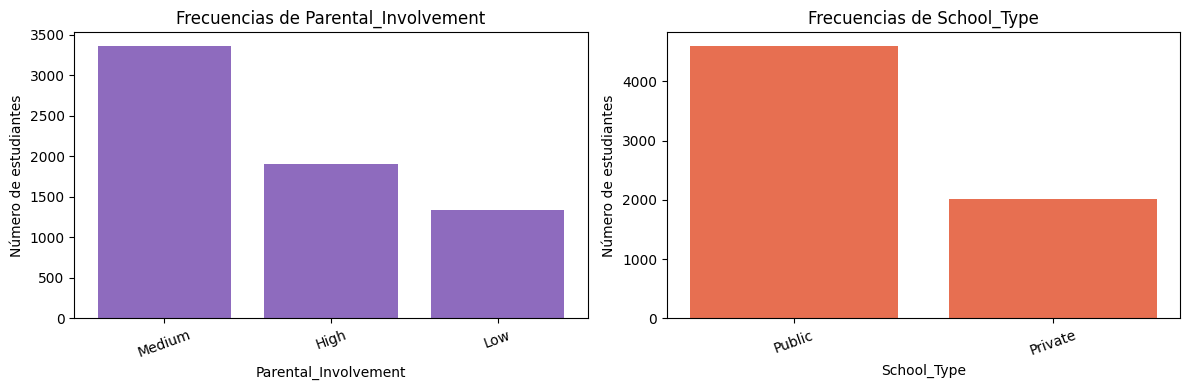

In [29]:
variables_categoricas = ['Parental_Involvement','School_Type']
for c in variables_categoricas:
    tabla = df[c].value_counts(dropna=False).to_frame('frecuencia')
    tabla['porcentaje'] = (tabla['frecuencia']/len(df)*100).round(2)
    print(f'\n{c}:\n{tabla.to_string()}')

fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, c, color in zip(axes, variables_categoricas, ['#8E6BBE','#E76F51']):
    counts = df[c].value_counts()
    ax.bar(counts.index.astype(str), counts.values, color=color)
    ax.set(title=f'Frecuencias de {c}', xlabel=c, ylabel='Número de estudiantes')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


**Interpretación categórica:** `Parental_Involvement` contiene tres niveles ordenables (`Low`, `Medium`, `High`), mientras que `School_Type` contiene dos clases nominales (`Public`, `Private`) sin jerarquía. No se detectan variantes por espacios o capitalización después de normalizar. Las tablas permiten reconocer el desequilibrio entre categorías; una categoría menos frecuente no es necesariamente errónea, pero debe conservarse al dividir los datos.


## 7. Codificación, escalamiento y organización reproducible

- **OrdinalEncoder:** se usa cuando existe un orden justificable (por ejemplo, bajo < medio < alto). Mantiene una sola columna con códigos ordenados.
- **OneHotEncoder:** se usa en variables nominales sin orden; crea una columna binaria por categoría y evita imponer una distancia artificial.
- **StandardScaler:** resta la media y divide por la desviación estándar. Cambia centro y escala, pero conserva el orden relativo y la forma lineal de la variable. Algoritmos basados en distancias, gradientes o regularización pueden dar peso excesivo a variables de mayor magnitud si no se escalan.

Documentación oficial: [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) y [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).


In [30]:
target = 'Exam_Score'
numeric_features = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity']
ordinal_features = ['Parental_Involvement','Access_to_Resources','Motivation_Level','Family_Income','Teacher_Quality','Peer_Influence','Parental_Education_Level','Distance_from_Home']
ordinal_categories = [
    ['Low','Medium','High'], ['Low','Medium','High'], ['Low','Medium','High'],
    ['Low','Medium','High'], ['Low','Medium','High'], ['Negative','Neutral','Positive'],
    ['High School','College','Postgraduate'], ['Near','Moderate','Far']
]
nominal_features = ['Extracurricular_Activities','Internet_Access','School_Type','Learning_Disabilities','Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_standard', StandardScaler(), numeric_features),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('nominal_onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features)
    ], remainder='drop', verbose_feature_names_out=False
)

X = df.drop(columns=target)
y = df[target].copy()
X_array = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_prepared = pd.DataFrame(X_array, columns=feature_names, index=df.index)
df_prepared = pd.concat([X_prepared, y], axis=1)
print(f'Matriz preparada: {df_prepared.shape[0]:,} filas x {df_prepared.shape[1]} columnas')
print('Variables de salida:')
print(df_prepared.columns.tolist())


Matriz preparada: 6,606 filas x 25 columnas
Variables de salida:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home', 'Extracurricular_Activities_No', 'Extracurricular_Activities_Yes', 'Internet_Access_No', 'Internet_Access_Yes', 'School_Type_Private', 'School_Type_Public', 'Learning_Disabilities_No', 'Learning_Disabilities_Yes', 'Gender_Female', 'Gender_Male', 'Exam_Score']


In [31]:
import numpy as np
import pandas as pd

# Verificar que existan los DataFrames necesarios
if "df" not in globals():
    raise NameError("No existe df. Ejecuta primero la celda de limpieza.")

if "X_prepared" not in globals():
    raise NameError(
        "No existe X_prepared. Ejecuta primero la celda del ColumnTransformer."
    )

# Columnas necesarias
columnas_numericas = [
    "Hours_Studied",
    "Attendance",
]

columnas_codificacion = [
    "Parental_Involvement",
    "School_Type_Private",
    "School_Type_Public",
]

columnas_faltantes_df = [
    columna
    for columna in [
        "Hours_Studied",
        "Attendance",
        "Parental_Involvement",
        "School_Type",
    ]
    if columna not in df.columns
]

columnas_faltantes_preparadas = [
    columna
    for columna in columnas_numericas + columnas_codificacion
    if columna not in X_prepared.columns
]

if columnas_faltantes_df:
    raise KeyError(
        f"Faltan columnas en df: {columnas_faltantes_df}"
    )

if columnas_faltantes_preparadas:
    raise KeyError(
        f"Faltan columnas en X_prepared: "
        f"{columnas_faltantes_preparadas}"
    )

# Comparación antes y después del escalamiento
valores_antes_escalamiento = (
    df[columnas_numericas]
    .head()
    .reset_index(drop=True)
    .add_suffix("_antes")
)

valores_despues_escalamiento = (
    X_prepared[columnas_numericas]
    .head()
    .reset_index(drop=True)
    .round(4)
    .add_suffix("_despues")
)

comparacion_escala = pd.concat(
    [
        valores_antes_escalamiento,
        valores_despues_escalamiento,
    ],
    axis=1,
)

print("COMPARACIÓN ANTES Y DESPUÉS DEL ESCALAMIENTO")
print(comparacion_escala.to_string(index=False))

print("\nCOMPROBACIÓN DESPUÉS DE STANDARDSCALER")
comprobacion_escalamiento = (
    X_prepared[columnas_numericas]
    .agg(["mean", "std"])
    .round(4)
)

print(comprobacion_escalamiento.to_string())

# Comparación antes y después de la codificación
valores_antes_codificacion = (
    df[["Parental_Involvement", "School_Type"]]
    .head()
    .reset_index(drop=True)
    .rename(columns={
        "Parental_Involvement": "Parental_Involvement_antes",
        "School_Type": "School_Type_antes",
    })
)

valores_despues_codificacion = (
    X_prepared[columnas_codificacion]
    .head()
    .reset_index(drop=True)
    .round(0)
    .astype(int)
    .rename(columns={
        "Parental_Involvement":
            "Parental_Involvement_ordinal_despues",
        "School_Type_Private":
            "School_Type_Private_despues",
        "School_Type_Public":
            "School_Type_Public_despues",
    })
)

comparacion_codificacion = pd.concat(
    [
        valores_antes_codificacion,
        valores_despues_codificacion,
    ],
    axis=1,
)

print("\nCOMPARACIÓN ANTES Y DESPUÉS DE LA CODIFICACIÓN")
print(comparacion_codificacion.to_string(index=False))

COMPARACIÓN ANTES Y DESPUÉS DEL ESCALAMIENTO
 Hours_Studied_antes  Attendance_antes  Hours_Studied_despues  Attendance_despues
                  23                84                 0.5051              0.3486
                  19                64                -0.1626             -1.3837
                  24                98                 0.6721              1.5613
                  29                89                 1.5068              0.7817
                  19                92                -0.1626              1.0416

COMPROBACIÓN DESPUÉS DE STANDARDSCALER
      Hours_Studied  Attendance
mean        -0.0000     -0.0000
std          1.0001      1.0001

COMPARACIÓN ANTES Y DESPUÉS DE LA CODIFICACIÓN
Parental_Involvement_antes School_Type_antes  Parental_Involvement_ordinal_despues  School_Type_Private_despues  School_Type_Public_despues
                       Low            Public                                     0                            0                           1

## 8. Prevención de fuga de información

En esta actividad se ajusta el transformador sobre el conjunto completo únicamente para producir el archivo solicitado. **Antes de entrenar un modelo real, primero se debe separar entrenamiento y prueba; después, la imputación, codificación y escala deben ajustarse (`fit`) solamente con entrenamiento y aplicarse (`transform`) a validación/prueba.** Incluir el `ColumnTransformer` dentro de un `Pipeline` con el estimador es la forma recomendada de evitar fuga de información.


## 9. Comparación inicial–final, exportación y verificación

La cantidad final de variables aumenta porque One-Hot Encoding expande las categorías nominales. La variable objetivo se conserva sin escalar.


In [32]:
from pathlib import Path
import numpy as np
import pandas as pd

# Verificar que existan los DataFrames necesarios
if "df_original" not in globals():
    raise NameError(
        "No existe df_original. Ejecuta primero la carga del CSV."
    )

if "df_prepared" not in globals():
    raise NameError(
        "No existe df_prepared. Ejecuta primero la transformación."
    )

if "Exam_Score" not in df_prepared.columns:
    raise KeyError(
        "df_prepared no contiene la variable objetivo Exam_Score."
    )

# Variables transformadas
variables_ordinales = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home",
]

variables_nominales = [
    "Extracurricular_Activities",
    "Internet_Access",
    "School_Type",
    "Learning_Disabilities",
    "Gender",
]

variables_escaladas = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
]

# Comparación del estado inicial y final
comparacion_estado = pd.DataFrame({
    "Elemento": [
        "Número de registros",
        "Número de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Variables categóricas transformadas",
        "Variables numéricas escaladas",
    ],
    "Estado inicial": [
        int(df_original.shape[0]),
        int(df_original.shape[1]),
        int(df_original.isna().sum().sum()),
        int(df_original.duplicated().sum()),
        "Sin transformar",
        "Sin escalar",
    ],
    "Estado final": [
        int(df_prepared.shape[0]),
        int(df_prepared.shape[1]),
        int(df_prepared.isna().sum().sum()),
        int(df_prepared.duplicated().sum()),
        (
            f"{len(variables_ordinales)} ordinales y "
            f"{len(variables_nominales)} nominales"
        ),
        f"{len(variables_escaladas)} variables",
    ],
})

print("COMPARACIÓN DEL ESTADO INICIAL Y FINAL")
print(comparacion_estado.to_string(index=False))

# Comprobar que todas las columnas estén en formato numérico
columnas_no_numericas = (
    df_prepared
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)

if columnas_no_numericas:
    raise TypeError(
        "El dataset preparado contiene columnas no numéricas: "
        f"{columnas_no_numericas}"
    )

# Comprobar valores faltantes
total_faltantes = int(df_prepared.isna().sum().sum())

if total_faltantes != 0:
    raise ValueError(
        f"El dataset preparado contiene {total_faltantes} "
        "valores faltantes."
    )

# Comprobar valores infinitos
matriz_numerica = df_prepared.to_numpy(dtype=float)

if not np.isfinite(matriz_numerica).all():
    raise ValueError(
        "El dataset preparado contiene valores infinitos."
    )

# Ruta para Google Colab
if Path("/content").exists():
    OUTPUT_PATH = Path("/content/csv_limpio.csv")
else:
    OUTPUT_PATH = Path.cwd() / "csv_limpio.csv"

# Exportar el archivo
df_prepared.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8",
)

# Recargar el archivo para verificarlo
verificacion = pd.read_csv(OUTPUT_PATH)

if verificacion.shape != df_prepared.shape:
    raise ValueError(
        "Las dimensiones cambiaron durante la exportación. "
        f"Antes: {df_prepared.shape}. "
        f"Después: {verificacion.shape}."
    )

if "Exam_Score" not in verificacion.columns:
    raise KeyError(
        "El CSV exportado no conserva Exam_Score."
    )

if int(verificacion.isna().sum().sum()) != 0:
    raise ValueError(
        "El CSV exportado contiene valores faltantes."
    )

if not np.isfinite(
    verificacion.to_numpy(dtype=float)
).all():
    raise ValueError(
        "El CSV exportado contiene valores no finitos."
    )

print("\nEXPORTACIÓN TERMINADA")
print(f"Archivo: {OUTPUT_PATH.name}")
print(f"Ruta: {OUTPUT_PATH}")
print(f"Dimensiones: {verificacion.shape}")
print("Exam_Score conservada: Sí")
print("\nPrimeros cinco registros:")
print(
    verificacion
    .head()
    .round(3)
    .to_string(index=False)
)

# Descargar el CSV en Google Colab
try:
    from google.colab import files

    files.download(str(OUTPUT_PATH))
except ImportError:
    print(
        "\nEl archivo quedó guardado en:",
        OUTPUT_PATH,
    )

COMPARACIÓN DEL ESTADO INICIAL Y FINAL
                           Elemento  Estado inicial              Estado final
                Número de registros            6607                      6606
                Número de variables              20                        25
                  Valores faltantes             235                         0
               Registros duplicados               0                         0
Variables categóricas transformadas Sin transformar 8 ordinales y 5 nominales
      Variables numéricas escaladas     Sin escalar               6 variables

EXPORTACIÓN TERMINADA
Archivo: csv_limpio.csv
Ruta: /content/csv_limpio.csv
Dimensiones: (6606, 25)
Exam_Score conservada: Sí

Primeros cinco registros:
 Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  Physical_Activity  Parental_Involvement  Access_to_Resources  Motivation_Level  Family_Income  Teacher_Quality  Peer_Influence  Parental_Education_Level  Distance_from_Home  Extracurri

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Conclusión

El diagnóstico identificó 235 valores faltantes en tres variables categóricas, ningún duplicado, tipos adecuados, categorías consistentes y un valor `Exam_Score = 101` fuera del rango porcentual asumido. La limpieza imputó los faltantes con la moda, normalizó nombres/categorías, aplicó conversiones defensivas y retiró únicamente esa fila imposible; los atípicos estadísticos plausibles se conservaron.

La preparación convirtió ocho variables ordenables mediante codificación ordinal, cinco nominales mediante One-Hot Encoding y estandarizó seis variables numéricas. La codificación permite que los algoritmos operen con números sin inventar jerarquías en categorías nominales; el escalamiento centra las variables y hace comparables sus magnitudes sin cambiar el orden relativo. El resultado conserva `Exam_Score`, carece de faltantes y puede recargarse como una matriz numérica.

Persisten limitaciones: la procedencia y definición operativa de cada variable deben contrastarse con un diccionario de datos; imputar con la moda puede aumentar la categoría mayoritaria; el valor 101 se filtró bajo una interpretación porcentual que debe confirmarse; el dataset es observacional y no demuestra causalidad; y aún deben evaluarse sesgos, representatividad y rendimiento fuera de muestra. El siguiente paso es separar entrenamiento/prueba, ajustar el preprocesamiento solo con entrenamiento, establecer un modelo base de regresión, validar con métricas como MAE/RMSE/R² y revisar residuos y equidad antes de elegir un modelo final.

## Referencias

1. Kaggle. *Student Performance Factors Dataset*: https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset  
2. Pandas. `DataFrame.fillna`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html  
3. Pandas. `DataFrame.drop_duplicates`: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html  
4. Scikit-learn. `ColumnTransformer`: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html  
5. Scikit-learn. `OneHotEncoder`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
6. Scikit-learn. `OrdinalEncoder`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html  
7. Scikit-learn. `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
